# ROI Attention Interpretation (Descriptive)

Questo notebook riscrive in modo piu descrittivo l'analisi delle ROI usate dal modello brain-to-audio.

L'obiettivo e produrre quattro tipi di figure:

1. `TokenMapper barplot`: importanza media delle ROI nel mapping neurale iniziale.
2. `Backbone barplot`: importanza media delle ROI nel backbone generativo.
3. `TokenMapper attention heatmap`: attenzione `query -> ROI` per un singolo sample.
4. `Backbone attention heatmap`: influenza delle ROI lungo i passi di denoising per un singolo sample.

Le stesse misure possono essere aggregate a tre livelli:

- **single sample**
- **categoria**
- **test set completo**

## Categorie del test set

Assumiamo 72 sample di test ordinati cosi:

- `0-11`: speech
- `12-23`: voice
- `24-35`: animals
- `36-47`: music
- `48-59`: nature
- `60-71`: tools

## Cosa viene mediato e cosa viene proiettato

### TokenMapper heatmap
- Mostra la matrice `query x ROI` per un singolo sample.
- I valori sono i pesi di cross-attention del `TokenMapper`.
- Qui **non** si fa media sui sample.
- Se l'attenzione ha dimensione multi-head, si fa media **solo sulle head**.

### TokenMapper barplot
Per ogni sample e ROI costruiamo uno score:

`roi_signal_score = mean_over_queries(attention_query_to_roi) * norm(roi_token)`

Quindi:
- si fa media sulle **query** per ottenere l'attenzione media di ogni ROI;
- si moltiplica per la norma del token della ROI dopo `ParcelMapper`;
- poi, per ottenere una figura di categoria o globale, si fa media sui **sample** del gruppo.

### Backbone heatmap
Il backbone non vede direttamente le ROI: vede i `brain tokens`.

Per ogni step selezionato del denoising:
- si registra l'attenzione del backbone verso i `brain tokens`;
- si fa media sulle **head** e sulle **posizioni latenti/query del backbone**;
- si ottiene quindi un vettore `brain_token_score`;
- questo vettore viene **proiettato** nello spazio ROI usando la matrice `query -> ROI` del `TokenMapper`.

La heatmap backbone mostra quindi, per un singolo sample:
- righe = step del denoising selezionati
- colonne = ROI
- valori = influenza della ROI dopo la proiezione dal backbone ai token e poi ai territori corticali.

### Backbone barplot
Per ogni sample:
- si prendono gli score ROI del backbone a tutti gli step selezionati;
- si fa media sui **processor** del backbone;
- poi si fa media sugli **step selezionati**;
- infine, per una figura di categoria o globale, si fa media sui **sample** del gruppo.

In sintesi:
- `TokenMapper heatmap` = struttura attentiva `query -> ROI`
- `TokenMapper barplot` = attenzione media x forza del segnale ROI
- `Backbone heatmap` = uso delle ROI lungo il denoising
- `Backbone barplot` = influenza media finale delle ROI nel generatore

In [1]:
import os
import sys
import math
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from diffusers import StableAudioPipeline
from diffusers.models.embeddings import apply_rotary_emb
from diffusers.pipelines.stable_audio.pipeline_stable_audio import get_1d_rotary_pos_embed

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dataset import build_datasets, ROI_LIST
from model import AudioNeuroAdapter, StableAudioIPAttnProcessor2_0

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
torch.set_grad_enabled(False)

In [2]:
CONFIG = {
    'data_path': '/srv/nfs-data/sisko/matteoc/maas_2023/pooled_data.pkl',
    'wav_dir': '/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav',
    'sound_names': '/home/matteoc/brainSounds/maas_data/SoundNames.npy',
    'ckpt_path': '/srv/nfs-data/sisko/matteoc/maas_2023/checkpoints/epoch_60.pt',
    'stable_audio_id': 'stabilityai/stable-audio-open-1.0',
    'cv': 'CV2',
    'split': 'test',
    'num_decoder_queries': 16,
    'conditioning_mode': 'empty_prompt_ip_adapter',
    'target_duration_s': 1.0,
    'target_sr': 44100,
    'num_inference_steps': 100,
    'guidance_scale': 3.0,
    'average_test_repeats': True,
    'selected_step_indices': [0,10,20,30,40,50,60,70,80,90,99],
    'base_seed': 42,
    'use_all_72_test_samples': True,
    'single_sample_to_plot': 0,
    'analysis_dir': './roi_attention_interpretation_descriptive_outputs',
}

analysis_dir = Path(CONFIG['analysis_dir'])
analysis_dir.mkdir(parents=True, exist_ok=True)
analysis_dir

PosixPath('roi_attention_interpretation_descriptive_outputs')

## Load model and dataset

In [3]:
device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')

ckpt = torch.load(CONFIG['ckpt_path'], map_location=device)
model_config = ckpt.get('model_config', {})

stable_audio_id = model_config.get('stable_audio_id', CONFIG['stable_audio_id'])
num_decoder_queries = model_config.get('num_decoder_queries', CONFIG['num_decoder_queries'])
target_duration_s = model_config.get('target_duration_s', CONFIG['target_duration_s'])
target_sr = model_config.get('target_sr', CONFIG['target_sr'])
cv = model_config.get('cv', CONFIG['cv'])
conditioning_mode = model_config.get('conditioning_mode', CONFIG['conditioning_mode'])
train_backbone_cross_attention = model_config.get('train_backbone_cross_attention', False)
train_cross_attention_proj = model_config.get('train_cross_attention_proj', False)

print('Loading Stable Audio pipeline...')
pipe = StableAudioPipeline.from_pretrained(stable_audio_id, torch_dtype=torch.float32).to(device)

model = AudioNeuroAdapter(
    pipe=pipe,
    num_rois=len(ROI_LIST),
    max_voxels=1024,
    num_decoder_queries=num_decoder_queries,
    target_duration_s=target_duration_s,
    conditioning_mode=conditioning_mode,
    train_backbone_cross_attention=train_backbone_cross_attention,
    train_cross_attention_proj=train_cross_attention_proj,
).to(device)

model.guidance_generator.load_state_dict(ckpt['guidance_generator'])
model.audio_proj.load_state_dict(ckpt['audio_proj'])
if ckpt.get('ip_adapter_scale') is not None:
    model.ip_adapter_scale.data.copy_(ckpt['ip_adapter_scale'].to(device=device, dtype=model.ip_adapter_scale.dtype))
if ckpt.get('brain_prompt_scale') is not None:
    model.brain_prompt_scale.data.copy_(ckpt['brain_prompt_scale'].to(device=device, dtype=model.brain_prompt_scale.dtype))
if model.ip_adapter_modules is not None and ckpt.get('ip_adapter_modules') is not None:
    model.ip_adapter_modules.load_state_dict(ckpt['ip_adapter_modules'])
if train_backbone_cross_attention and ckpt.get('trainable_backbone') is not None:
    model.pipe.transformer.load_state_dict(ckpt['trainable_backbone'])
if ckpt.get('_brain_norm_mean') is not None:
    model._brain_norm_mean = ckpt['_brain_norm_mean'].to(device)
    model._brain_norm_std = ckpt['_brain_norm_std'].to(device)
model.eval()

with open(CONFIG['data_path'], 'rb') as f:
    pooled_data = pickle.load(f)
sound_names = np.load(CONFIG['sound_names'], allow_pickle=True)
saved_normalizer = model.get_brain_normalizer()

train_ds, test_ds = build_datasets(
    pooled_data=pooled_data,
    cv=cv,
    wav_dir=CONFIG['wav_dir'],
    sound_names=sound_names,
    target_sr=target_sr,
    target_len_s=target_duration_s,
    average_test_repeats=CONFIG['average_test_repeats'] and CONFIG['split'] == 'test',
    brain_normalizer_override=saved_normalizer,
)

dataset = test_ds if CONFIG['split'] == 'test' else train_ds
selected_indices = list(range(72)) if CONFIG['use_all_72_test_samples'] else list(range(len(dataset)))

print('Device:', device)
print('ROI list:', ROI_LIST)
print('Number of selected samples:', len(selected_indices))

/tmp/ipykernel_2791841/86974627.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CONFIG['ckpt_path'], map_location=device)


Loading Stable Audio pipeline...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Train: 1080 campioni | Test: 72 campioni
  brain_data shape: 6 ROI × 1024 voxels
  audio_target:     44100 samples @ 44100Hz (1.0s)
Device: cuda:2
ROI list: ['HG2hem', 'PT2hem', 'PP2hem', 'mSTG2hem', 'pSTG2hem', 'aSTG2hem']
Number of selected samples: 72


## Category helpers

Definiamo i gruppi di sample del test set secondo la convenzione 6 categorie x 12 sample.

In [4]:
CATEGORY_NAMES = ['speech', 'voice', 'animals', 'music', 'nature', 'tools']

def sample_idx_to_category(sample_idx: int) -> str:
    category_id = int(sample_idx) // 12
    return CATEGORY_NAMES[category_id]

CATEGORY_TO_SAMPLE_INDICES = {
    category: list(range(i * 12, (i + 1) * 12))
    for i, category in enumerate(CATEGORY_NAMES)
}

CATEGORY_TO_SAMPLE_INDICES

{'speech': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 'voice': [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23],
 'animals': [24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35],
 'music': [36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47],
 'nature': [48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59],
 'tools': [60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]}

## Helper functions

Queste funzioni implementano i passaggi chiave dell'analisi.

### `extract_tokenmapper_attention`
Per un singolo sample:
- calcola i token ROI dopo `ParcelMapper`;
- estrae la matrice di attenzione `query -> ROI` dal `TokenMapper`;
- costruisce lo score `roi_signal_score = mean_over_queries(attention) * norm(roi_token)`.

### `RecordingIPAttnProcessor`
Registra l'attenzione del backbone verso i `brain tokens` nei passi selezionati del denoising.

### `run_backbone_attention_analysis`
Per un singolo sample:
- estrae la mappa `query -> ROI` del `TokenMapper`;
- registra l'attenzione del backbone verso i `brain tokens`;
- proietta l'attenzione dal backbone alle ROI con:

`roi_score = backbone_token_attention @ tokenmapper_query_to_roi_attention`

Questa e la proiezione centrale che trasforma l'uso dei token nel backbone in influenza ROI.

In [5]:
def make_scheduler():
    return pipe.scheduler.__class__.from_config(pipe.scheduler.config)

def make_initial_latents(batch_size, seed):
    scheduler = make_scheduler()
    waveform_length = int(pipe.transformer.config.sample_size)
    latent_shape = (batch_size, pipe.transformer.config.in_channels, waveform_length)
    generator = torch.Generator(device=device)
    generator.manual_seed(int(seed))
    latents = torch.randn(latent_shape, generator=generator, device=device, dtype=torch.float32)
    latents = latents * scheduler.init_noise_sigma
    return latents

def extract_tokenmapper_attention(brain):
    guidance = model.guidance_generator
    token_mapper = guidance.token_mapper

    fmri_tokens = guidance.parcel_mapper(brain)  # [B, P, D]
    B, P, D = fmri_tokens.shape

    src = fmri_tokens.permute(0, 2, 1).unsqueeze(-1)
    pos_embed = token_mapper.roi_embeddings.weight.unsqueeze(0).repeat(B, 1, 1).permute(0, 2, 1).unsqueeze(-1)
    memory = src.flatten(2).permute(2, 0, 1)
    pos = pos_embed.flatten(2).permute(2, 0, 1)
    query_embed = token_mapper.decoder_queries.weight.unsqueeze(1).repeat(1, B, 1)
    tgt = torch.zeros_like(query_embed)
    key_padding_mask = torch.zeros(B, P, device=brain.device, dtype=torch.bool)

    layer = token_mapper.transformer.decoder.layers[0]
    tgt2 = layer.norm1(tgt)
    _, attn_weights = layer.multihead_attn(
        query=layer.with_pos_embed(tgt2, query_embed),
        key=layer.with_pos_embed(memory, pos),
        value=memory,
        key_padding_mask=key_padding_mask,
        need_weights=True,
        average_attn_weights=False,
    )

    if attn_weights.dim() == 4:
        query_roi_attn = attn_weights.mean(dim=1)  # media sulle heads -> [B, Q, P]
    elif attn_weights.dim() == 3:
        query_roi_attn = attn_weights
    else:
        raise ValueError(f'Unexpected attention shape: {tuple(attn_weights.shape)}')

    roi_attn_mean = query_roi_attn.mean(dim=1)     # media sulle query -> [B, P]
    roi_token_norm = fmri_tokens.norm(dim=-1)      # [B, P]
    roi_signal_score = roi_attn_mean * roi_token_norm

    return {
        'fmri_tokens': fmri_tokens.detach(),
        'query_roi_attn': query_roi_attn.detach(),
        'roi_attn_mean': roi_attn_mean.detach(),
        'roi_token_norm': roi_token_norm.detach(),
        'roi_signal_score': roi_signal_score.detach(),
    }

class RecordingIPAttnProcessor(nn.Module):
    def __init__(self, name, base_processor, record_store):
        super().__init__()
        self.name = name
        self.hidden_size = base_processor.hidden_size
        self.cross_attention_dim = base_processor.cross_attention_dim
        self.num_tokens = base_processor.num_tokens
        self.scale = base_processor.scale
        self.to_k_ip = nn.Linear(self.cross_attention_dim, self.hidden_size, bias=False)
        self.to_v_ip = nn.Linear(self.cross_attention_dim, self.hidden_size, bias=False)
        self.to_k_ip.load_state_dict(base_processor.to_k_ip.state_dict())
        self.to_v_ip.load_state_dict(base_processor.to_v_ip.state_dict())
        base_device = base_processor.to_k_ip.weight.device
        base_dtype = base_processor.to_k_ip.weight.dtype
        self.to_k_ip.to(device=base_device, dtype=base_dtype)
        self.to_v_ip.to(device=base_device, dtype=base_dtype)
        self.record_store = record_store

    def __call__(self, attn, hidden_states, encoder_hidden_states=None, attention_mask=None, rotary_emb=None):
        residual = hidden_states
        input_ndim = hidden_states.ndim

        if input_ndim == 4:
            batch_size, channel, height, width = hidden_states.shape
            hidden_states = hidden_states.view(batch_size, channel, height * width).transpose(1, 2)
        else:
            batch_size = hidden_states.shape[0]

        if encoder_hidden_states is None:
            encoder_hidden_states = hidden_states
            ip_hidden_states = None
        else:
            split_idx = encoder_hidden_states.shape[1] - self.num_tokens
            encoder_hidden_states, ip_hidden_states = (
                encoder_hidden_states[:, :split_idx, :],
                encoder_hidden_states[:, split_idx:, :],
            )
            if attn.norm_cross:
                encoder_hidden_states = attn.norm_encoder_hidden_states(encoder_hidden_states)

        sequence_length = encoder_hidden_states.shape[1]
        if attention_mask is not None:
            attention_mask = attn.prepare_attention_mask(attention_mask, sequence_length, batch_size)
            attention_mask = attention_mask.view(batch_size, attn.heads, -1, attention_mask.shape[-1])

        query = attn.to_q(hidden_states)
        key = attn.to_k(encoder_hidden_states)
        value = attn.to_v(encoder_hidden_states)

        head_dim = query.shape[-1] // attn.heads
        kv_heads = key.shape[-1] // head_dim

        query = query.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        key = key.view(batch_size, -1, kv_heads, head_dim).transpose(1, 2)
        value = value.view(batch_size, -1, kv_heads, head_dim).transpose(1, 2)

        if kv_heads != attn.heads:
            heads_per_kv_head = attn.heads // kv_heads
            key = torch.repeat_interleave(key, heads_per_kv_head, dim=1, output_size=key.shape[1] * heads_per_kv_head)
            value = torch.repeat_interleave(value, heads_per_kv_head, dim=1, output_size=value.shape[1] * heads_per_kv_head)

        if attn.norm_q is not None:
            query = attn.norm_q(query)
        if attn.norm_k is not None:
            key = attn.norm_k(key)

        if rotary_emb is not None:
            query_dtype = query.dtype
            key_dtype = key.dtype
            query = query.to(torch.float32)
            key = key.to(torch.float32)
            rot_dim = rotary_emb[0].shape[-1]
            query_to_rotate, query_unrotated = query[..., :rot_dim], query[..., rot_dim:]
            query_rotated = apply_rotary_emb(query_to_rotate, rotary_emb, use_real=True, use_real_unbind_dim=-2)
            query = torch.cat((query_rotated, query_unrotated), dim=-1)
            if not attn.is_cross_attention:
                key_to_rotate, key_unrotated = key[..., :rot_dim], key[..., rot_dim:]
                key_rotated = apply_rotary_emb(key_to_rotate, rotary_emb, use_real=True, use_real_unbind_dim=-2)
                key = torch.cat((key_rotated, key_unrotated), dim=-1)
            query = query.to(query_dtype)
            key = key.to(key_dtype)

        hidden_states = F.scaled_dot_product_attention(
            query, key, value, attn_mask=attention_mask, dropout_p=0.0, is_causal=False
        )

        if ip_hidden_states is not None:
            ip_key = self.to_k_ip(ip_hidden_states)
            ip_value = self.to_v_ip(ip_hidden_states)

            ip_key = ip_key.view(batch_size, -1, kv_heads, head_dim).transpose(1, 2)
            ip_value = ip_value.view(batch_size, -1, kv_heads, head_dim).transpose(1, 2)

            if kv_heads != attn.heads:
                heads_per_kv_head = attn.heads // kv_heads
                ip_key = torch.repeat_interleave(ip_key, heads_per_kv_head, dim=1, output_size=ip_key.shape[1] * heads_per_kv_head)
                ip_value = torch.repeat_interleave(ip_value, heads_per_kv_head, dim=1, output_size=ip_value.shape[1] * heads_per_kv_head)

            if attn.norm_k is not None:
                ip_key = attn.norm_k(ip_key)

            scale = 1.0 / math.sqrt(head_dim)
            ip_scores = torch.matmul(query, ip_key.transpose(-2, -1)) * scale
            ip_attn = torch.softmax(ip_scores, dim=-1)

            if self.record_store['active'] and self.record_store['current_step'] in self.record_store['selected_steps']:
                token_attn = ip_attn.mean(dim=(1, 2)).detach().cpu()  # media su heads e posizioni -> [B, num_tokens]
                self.record_store['records'].append({
                    'step_idx': self.record_store['current_step'],
                    'processor_name': self.name,
                    'token_attn': token_attn,
                })

            ip_hidden_states = torch.matmul(ip_attn, ip_value)
            hidden_states = hidden_states + self.scale * ip_hidden_states

        hidden_states = hidden_states.transpose(1, 2).reshape(batch_size, -1, attn.heads * head_dim)
        hidden_states = hidden_states.to(query.dtype)
        hidden_states = attn.to_out[0](hidden_states)
        hidden_states = attn.to_out[1](hidden_states)

        if input_ndim == 4:
            hidden_states = hidden_states.transpose(-1, -2).reshape(batch_size, channel, height, width)
        if attn.residual_connection:
            hidden_states = hidden_states + residual
        hidden_states = hidden_states / attn.rescale_output_factor
        return hidden_states

def install_ip_attention_recorders(record_store):
    transformer = model.pipe.transformer
    original_procs = transformer.attn_processors
    new_procs = {}
    for name, proc in original_procs.items():
        if isinstance(proc, StableAudioIPAttnProcessor2_0):
            new_procs[name] = RecordingIPAttnProcessor(name=name, base_processor=proc, record_store=record_store)
        else:
            new_procs[name] = proc
    transformer.set_attn_processor(new_procs)
    return original_procs

def restore_attn_processors(original_procs):
    model.pipe.transformer.set_attn_processor(original_procs)

def run_backbone_attention_analysis(brain, seed, num_inference_steps, guidance_scale, selected_step_indices):
    B = brain.shape[0]
    assert B == 1, "Questo notebook assume batch_size=1 per l'analisi interpretativa."

    token_pack = extract_tokenmapper_attention(brain)
    query_roi_attn = token_pack['query_roi_attn'][0].detach().cpu().numpy()  # [Q, P]

    text_audio_duration_embeds, audio_duration_embeds = model.build_conditioning(brain_data=brain, device=device)
    uncond_embeds = None
    uncond_audio_duration_embeds = None
    if guidance_scale != 1.0:
        uncond_embeds, uncond_audio_duration_embeds = model.build_unconditional_conditioning(
            batch_size=B,
            device=device,
            dtype=text_audio_duration_embeds.dtype,
        )

    scheduler = make_scheduler()
    scheduler.set_timesteps(num_inference_steps, device=device)
    latents = make_initial_latents(batch_size=B, seed=seed)

    rotary_embedding = get_1d_rotary_pos_embed(
        pipe.rotary_embed_dim,
        latents.shape[2] + audio_duration_embeds.shape[1],
        use_real=True,
        repeat_interleave_real=False,
    )
    rotary_embedding = tuple(r.to(device) for r in rotary_embedding)

    selected_step_indices = sorted(set(int(s) for s in selected_step_indices if 0 <= int(s) < num_inference_steps))
    record_store = {
        'records': [],
        'selected_steps': selected_step_indices,
        'current_step': None,
        'active': False,
    }

    original_procs = install_ip_attention_recorders(record_store)
    try:
        for step_idx, t in enumerate(scheduler.timesteps):
            latent_input = scheduler.scale_model_input(latents, t)

            record_store['current_step'] = step_idx
            record_store['active'] = True
            noise_pred_cond = model.pipe.transformer(
                hidden_states=latent_input,
                timestep=t.unsqueeze(0).expand(B),
                encoder_hidden_states=text_audio_duration_embeds,
                global_hidden_states=audio_duration_embeds,
                rotary_embedding=rotary_embedding,
                return_dict=False,
            )[0]

            if guidance_scale == 1.0:
                noise_pred = noise_pred_cond
            else:
                record_store['active'] = False
                noise_pred_uncond = model.pipe.transformer(
                    hidden_states=latent_input,
                    timestep=t.unsqueeze(0).expand(B),
                    encoder_hidden_states=uncond_embeds,
                    global_hidden_states=uncond_audio_duration_embeds,
                    rotary_embedding=rotary_embedding,
                    return_dict=False,
                )[0]
                noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_cond - noise_pred_uncond)

            latents = scheduler.step(noise_pred, t, latents).prev_sample
    finally:
        restore_attn_processors(original_procs)

    backbone_records = []
    for rec in record_store['records']:
        token_attn = rec['token_attn'][0].numpy()  # [Q]
        roi_scores = token_attn @ query_roi_attn   # proiezione dai token alle ROI -> [P]
        for roi_idx, roi_name in enumerate(ROI_LIST):
            backbone_records.append({
                'step_idx': rec['step_idx'],
                'processor_name': rec['processor_name'],
                'roi': roi_name,
                'roi_backbone_score': float(roi_scores[roi_idx]),
            })

    backbone_df = pd.DataFrame(backbone_records)
    return token_pack, backbone_df

## Compute per-sample attribution once

Questa e la parte piu costosa del notebook. Viene eseguita **una sola volta**.

Per ogni sample salviamo:
- `token_roi_df`: score ROI del `TokenMapper` per sample
- `backbone_roi_df`: score ROI del `Backbone` per sample, gia mediati su processor e step selezionati
- `sample_summary_df`: ROI dominante per sample nei due livelli
- `backbone_step_roi_df`: score ROI del backbone per sample e step, utile per la heatmap single-sample

### Dove si fa media qui
- `TokenMapper`: media sulle query, **non** sui sample
- `Backbone`: media sui processor e poi sugli step selezionati per costruire lo score per-sample
- nessuna media sui sample in questa cella

In [6]:
token_roi_records = []
backbone_roi_records = []
backbone_step_roi_records = []
sample_summary_records = []

for sample_idx in tqdm(selected_indices, desc='Per-sample ROI attribution'):
    batch = dataset[sample_idx]
    brain = batch['brain_data'].unsqueeze(0).to(device)
    sound_idx = int(batch['sound_idx'])
    category = sample_idx_to_category(sample_idx)
    seed = CONFIG['base_seed'] + sample_idx

    token_pack, backbone_df = run_backbone_attention_analysis(
        brain=brain,
        seed=seed,
        num_inference_steps=CONFIG['num_inference_steps'],
        guidance_scale=CONFIG['guidance_scale'],
        selected_step_indices=CONFIG['selected_step_indices'],
    )

    token_scores = token_pack['roi_signal_score'][0].detach().cpu().numpy()
    for roi_idx, roi_name in enumerate(ROI_LIST):
        token_roi_records.append({
            'sample_idx': sample_idx,
            'sound_idx': sound_idx,
            'category': category,
            'roi': roi_name,
            'tokenmapper_roi_score': float(token_scores[roi_idx]),
        })

    # backbone per step: media sui processor mantenendo step e ROI separati
    backbone_step_df = backbone_df.groupby(['step_idx', 'roi'], as_index=False)['roi_backbone_score'].mean()
    backbone_step_df['sample_idx'] = sample_idx
    backbone_step_df['sound_idx'] = sound_idx
    backbone_step_df['category'] = category
    backbone_step_roi_records.extend(backbone_step_df.to_dict('records'))

    # backbone per sample: media sugli step selezionati (dopo la media sui processor)
    backbone_mean_df = backbone_step_df.groupby('roi', as_index=False)['roi_backbone_score'].mean()
    backbone_mean_df['sample_idx'] = sample_idx
    backbone_mean_df['sound_idx'] = sound_idx
    backbone_mean_df['category'] = category
    backbone_roi_records.extend(backbone_mean_df.to_dict('records'))

    token_top = max(zip(ROI_LIST, token_scores), key=lambda x: x[1])
    backbone_top_row = backbone_mean_df.sort_values('roi_backbone_score', ascending=False).iloc[0]

    sample_summary_records.append({
        'sample_idx': sample_idx,
        'sound_idx': sound_idx,
        'category': category,
        'tokenmapper_top_roi': token_top[0],
        'tokenmapper_top_score': float(token_top[1]),
        'backbone_top_roi': backbone_top_row['roi'],
        'backbone_top_score': float(backbone_top_row['roi_backbone_score']),
        'token_backbone_agree': bool(token_top[0] == backbone_top_row['roi']),
    })

token_roi_df = pd.DataFrame(token_roi_records)
backbone_roi_df = pd.DataFrame(backbone_roi_records)
backbone_step_roi_df = pd.DataFrame(backbone_step_roi_records)
sample_summary_df = pd.DataFrame(sample_summary_records)

token_roi_df.to_csv(analysis_dir / 'token_roi_scores_per_sample.csv', index=False)
backbone_roi_df.to_csv(analysis_dir / 'backbone_roi_scores_per_sample.csv', index=False)
backbone_step_roi_df.to_csv(analysis_dir / 'backbone_roi_scores_per_sample_per_step.csv', index=False)
sample_summary_df.to_csv(analysis_dir / 'sample_roi_summary.csv', index=False)

sample_summary_df.head()

Per-sample ROI attribution:   0%|          | 0/72 [00:00<?, ?it/s]

/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/torchsde/_brownian/brownian_interval.py:608: UserWarning: Should have tb<=t1 but got tb=500.00006103515625 and t1=500.0.
  warnings.warn(f"Should have {tb_name}<=t1 but got {tb_name}={tb} and t1={self._end}.")
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/torchsde/_brownian/brownian_interval.py:599: UserWarning: Should have ta>=t0 but got ta=0.29999998211860657 and t0=0.3.
  warnings.warn(f"Should have ta>=t0 but got ta={ta} and t0={self._start}.")
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/torchsde/_brownian/brownian_interval.py:599: UserWarning: Should have ta>=t0 but got ta=0.0 and t0=0.3.
  warnings.warn(f"Should have ta>=t0 but got ta={ta} and t0={self._start}.")
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/torchsde/_brownian/brownian_interval.py:602: UserWarning: Should have tb>=t0 but got tb=0.29999998211860657 and t0=0.3.
  warnings.warn(f"Should hav

,sample_idx,sound_idx,category,tokenmapper_top_roi,tokenmapper_top_score,backbone_top_roi,backbone_top_score,token_backbone_agree
0,0,0,speech,mSTG2hem,0.481851,HG2hem,0.229107,False
1,1,1,speech,mSTG2hem,0.417570,PP2hem,0.229784,False
2,2,2,speech,mSTG2hem,0.395368,PP2hem,0.228675,False
3,3,10,speech,PP2hem,0.405107,PP2hem,0.230097,True
4,4,11,speech,mSTG2hem,0.518544,HG2hem,0.230592,False


## Plot helpers

Queste funzioni producono le figure nei tre livelli richiesti:
- test set completo
- categoria
- singolo sample

### `plot_group_barplots`
Input: una lista di `sample_idx`.

Output:
- barplot TokenMapper: media del `tokenmapper_roi_score` sui sample del gruppo
- barplot Backbone: media del `roi_backbone_score` sui sample del gruppo

### `plot_single_sample_heatmaps`
Input: un singolo `sample_idx`.

Output:
- `TokenMapper attention` heatmap = matrice `query x ROI` del sample
- `Backbone attention` heatmap = matrice `step x ROI` del sample, mediata sui processor

In [7]:
def plot_group_barplots(sample_indices, group_name, save_prefix=None):
    token_group_df = (
        token_roi_df[token_roi_df['sample_idx'].isin(sample_indices)]
        .groupby('roi', as_index=False)['tokenmapper_roi_score']
        .mean()
        .sort_values('tokenmapper_roi_score', ascending=False)
    )

    backbone_group_df = (
        backbone_roi_df[backbone_roi_df['sample_idx'].isin(sample_indices)]
        .groupby('roi', as_index=False)['roi_backbone_score']
        .mean()
        .sort_values('roi_backbone_score', ascending=False)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].barh(token_group_df['roi'][::-1], token_group_df['tokenmapper_roi_score'][::-1])
    axes[0].set_title(f'{group_name} | TokenMapper')
    axes[0].set_xlabel('Mean ROI score across selected samples')

    axes[1].barh(backbone_group_df['roi'][::-1], backbone_group_df['roi_backbone_score'][::-1])
    axes[1].set_title(f'{group_name} | Backbone')
    axes[1].set_xlabel('Mean ROI score across selected samples')

    plt.tight_layout()
    if save_prefix is not None:
        plt.savefig(analysis_dir / f'{save_prefix}_roi_barplots.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'{group_name} | TokenMapper ranking')
    display(token_group_df)
    print(f'{group_name} | Backbone ranking')
    display(backbone_group_df)

    return token_group_df, backbone_group_df

def plot_single_sample_heatmaps(sample_idx, save_prefix=None):
    batch = dataset[sample_idx]
    brain = batch['brain_data'].unsqueeze(0).to(device)
    sound_idx = int(batch['sound_idx'])
    category = sample_idx_to_category(sample_idx)
    seed = CONFIG['base_seed'] + sample_idx

    token_pack, backbone_df = run_backbone_attention_analysis(
        brain=brain,
        seed=seed,
        num_inference_steps=CONFIG['num_inference_steps'],
        guidance_scale=CONFIG['guidance_scale'],
        selected_step_indices=CONFIG['selected_step_indices'],
    )

    token_heatmap = pd.DataFrame(
        token_pack['query_roi_attn'][0].detach().cpu().numpy(),
        columns=ROI_LIST,
    )

    backbone_heatmap = (
        backbone_df.groupby(['step_idx', 'roi'], as_index=False)['roi_backbone_score']
        .mean()
        .pivot(index='step_idx', columns='roi', values='roi_backbone_score')[ROI_LIST]
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    im0 = axes[0].imshow(token_heatmap.values, aspect='auto', cmap='magma')
    axes[0].set_title(f'TokenMapper attention | sample_idx={sample_idx} | sound_idx={sound_idx} | category={category}')
    axes[0].set_xlabel('ROI')
    axes[0].set_ylabel('Query index')
    axes[0].set_xticks(range(len(ROI_LIST)))
    axes[0].set_xticklabels(ROI_LIST, rotation=45, ha='right')
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(backbone_heatmap.values, aspect='auto', cmap='viridis')
    axes[1].set_title(f'Backbone ROI influence | sample_idx={sample_idx} | sound_idx={sound_idx} | category={category}')
    axes[1].set_xlabel('ROI')
    axes[1].set_ylabel('Step index')
    axes[1].set_xticks(range(len(ROI_LIST)))
    axes[1].set_xticklabels(ROI_LIST, rotation=45, ha='right')
    axes[1].set_yticks(range(len(backbone_heatmap.index)))
    axes[1].set_yticklabels(list(backbone_heatmap.index))
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    if save_prefix is not None:
        plt.savefig(analysis_dir / f'{save_prefix}_sample_{sample_idx:03d}_heatmaps.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Single-sample summary')
    display(sample_summary_df[sample_summary_df['sample_idx'] == sample_idx])

    return token_heatmap, backbone_heatmap


## 1. Overall results on the full test set

Qui la media finale e fatta sui **72 sample del test set**.

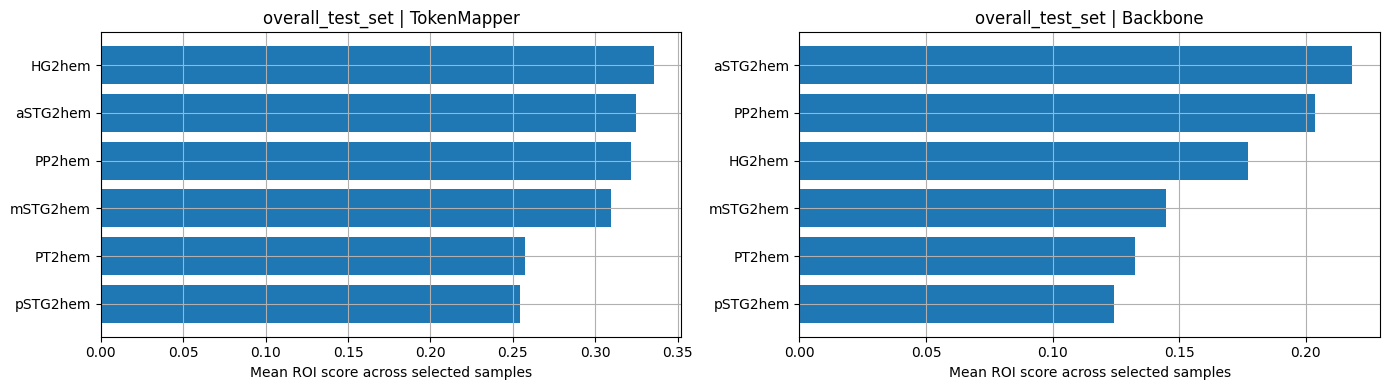

overall_test_set | TokenMapper ranking


,roi,tokenmapper_roi_score
0,HG2hem,0.335398
3,aSTG2hem,0.324423
1,PP2hem,0.321351
4,mSTG2hem,0.309370
2,PT2hem,0.257409
5,pSTG2hem,0.254140


overall_test_set | Backbone ranking


,roi,roi_backbone_score
3,aSTG2hem,0.218356
1,PP2hem,0.203445
0,HG2hem,0.177063
4,mSTG2hem,0.144697
2,PT2hem,0.132355
5,pSTG2hem,0.124084


In [8]:
overall_token_df, overall_backbone_df = plot_group_barplots(
    sample_indices=selected_indices,
    group_name='overall_test_set',
    save_prefix='overall_test_set',
)


## 2. Category-level results

Qui la media finale e fatta sui **12 sample** di ciascuna categoria.

Ogni categoria produce due barplot:
- media TokenMapper della categoria
- media Backbone della categoria

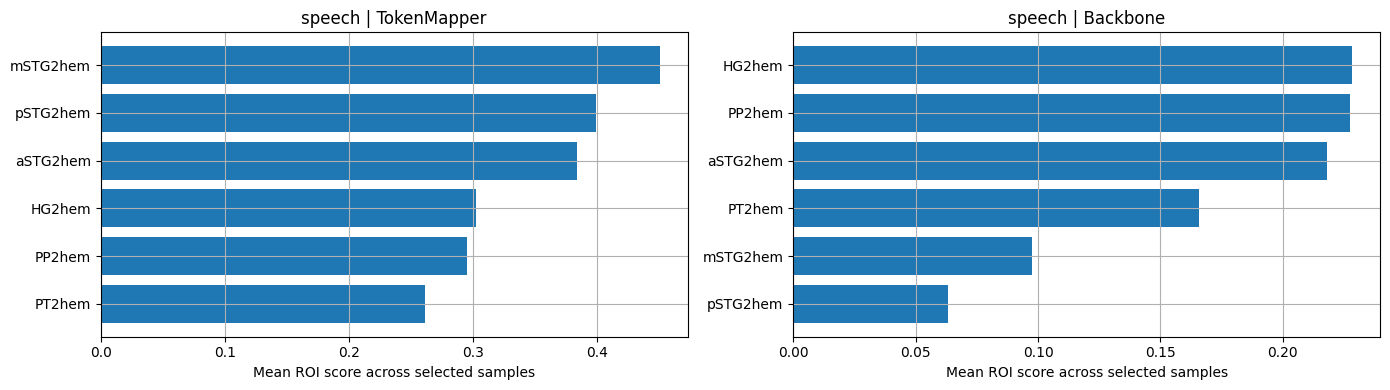

speech | TokenMapper ranking


,roi,tokenmapper_roi_score
4,mSTG2hem,0.450800
5,pSTG2hem,0.399897
3,aSTG2hem,0.384539
0,HG2hem,0.302553
1,PP2hem,0.295268
2,PT2hem,0.261793


speech | Backbone ranking


,roi,roi_backbone_score
0,HG2hem,0.228240
1,PP2hem,0.227352
3,aSTG2hem,0.217873
2,PT2hem,0.165591
4,mSTG2hem,0.097570
5,pSTG2hem,0.063374


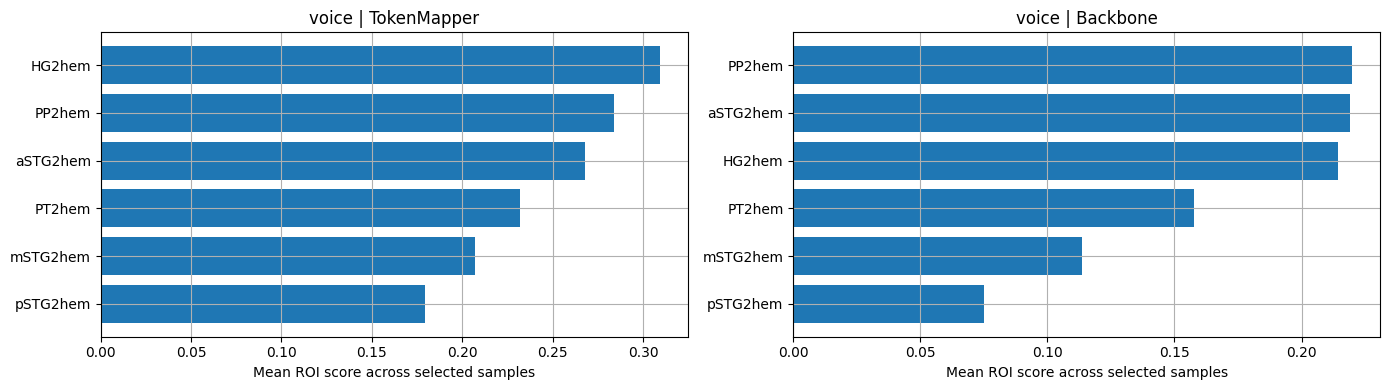

voice | TokenMapper ranking


,roi,tokenmapper_roi_score
0,HG2hem,0.309183
1,PP2hem,0.284203
3,aSTG2hem,0.267861
2,PT2hem,0.232138
4,mSTG2hem,0.207259
5,pSTG2hem,0.179316


voice | Backbone ranking


,roi,roi_backbone_score
1,PP2hem,0.219884
3,aSTG2hem,0.219243
0,HG2hem,0.214450
2,PT2hem,0.157806
4,mSTG2hem,0.113437
5,pSTG2hem,0.075180


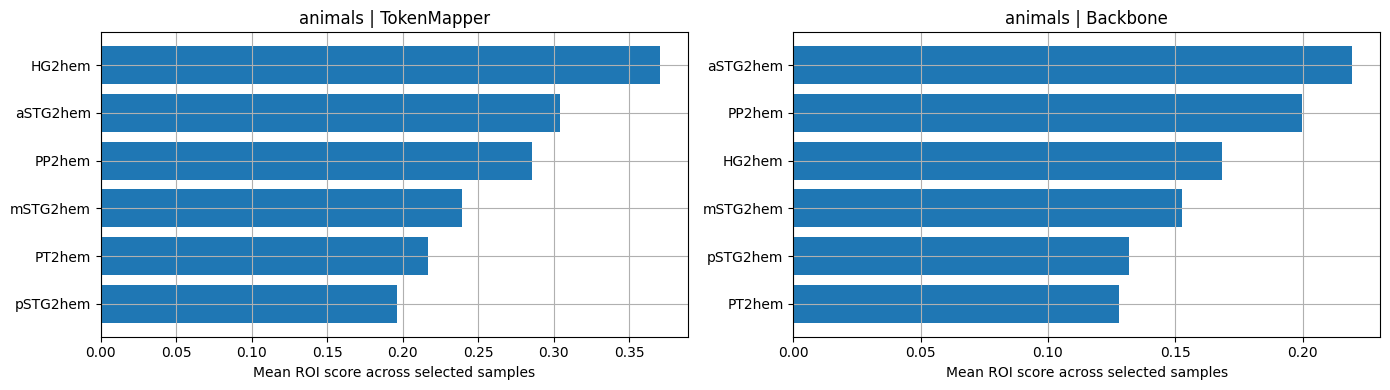

animals | TokenMapper ranking


,roi,tokenmapper_roi_score
0,HG2hem,0.370221
3,aSTG2hem,0.304219
1,PP2hem,0.285584
4,mSTG2hem,0.239205
2,PT2hem,0.216981
5,pSTG2hem,0.196308


animals | Backbone ranking


,roi,roi_backbone_score
3,aSTG2hem,0.219445
1,PP2hem,0.199811
0,HG2hem,0.168413
4,mSTG2hem,0.152638
5,pSTG2hem,0.131766
2,PT2hem,0.127927


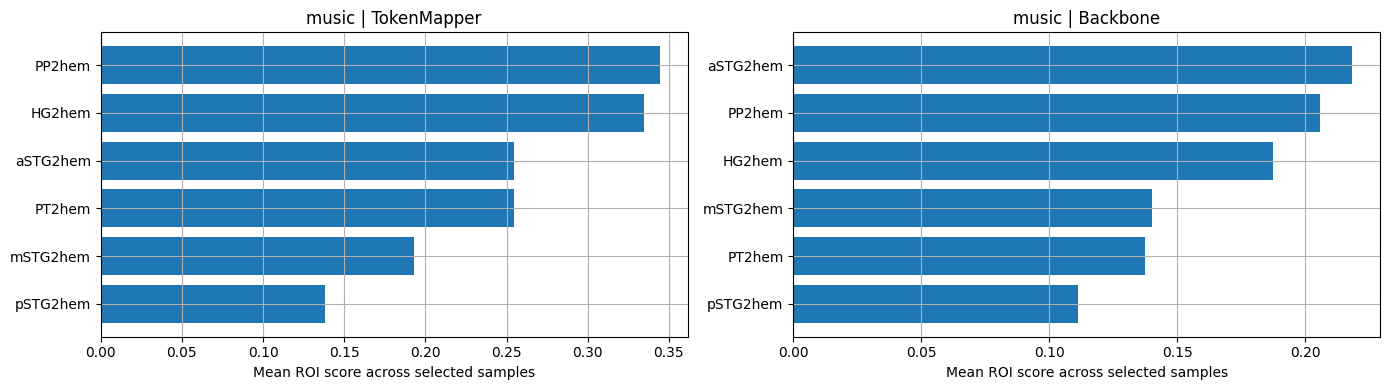

music | TokenMapper ranking


,roi,tokenmapper_roi_score
1,PP2hem,0.344264
0,HG2hem,0.334605
3,aSTG2hem,0.254610
2,PT2hem,0.254429
4,mSTG2hem,0.192770
5,pSTG2hem,0.138104


music | Backbone ranking


,roi,roi_backbone_score
3,aSTG2hem,0.218195
1,PP2hem,0.205678
0,HG2hem,0.187455
4,mSTG2hem,0.140133
2,PT2hem,0.137206
5,pSTG2hem,0.111334


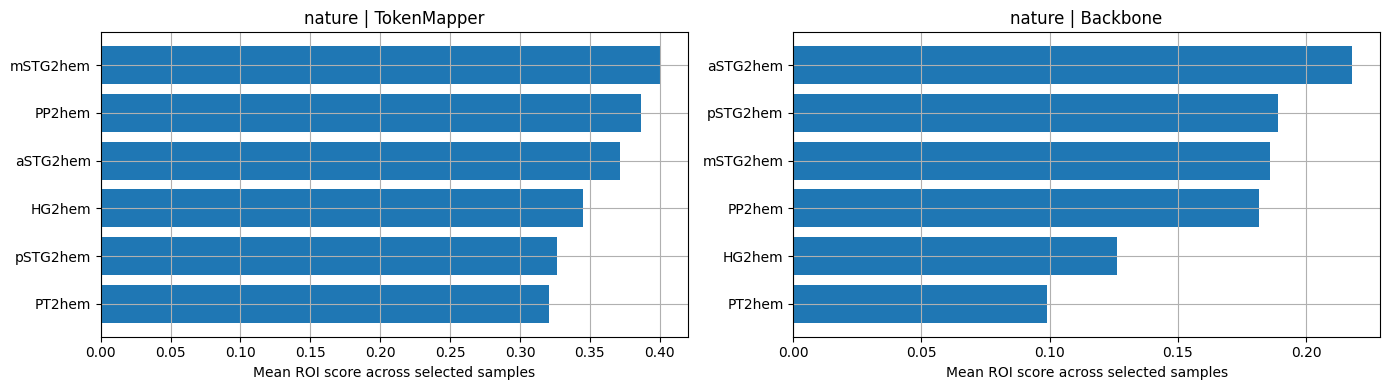

nature | TokenMapper ranking


,roi,tokenmapper_roi_score
4,mSTG2hem,0.399913
1,PP2hem,0.386914
3,aSTG2hem,0.371517
0,HG2hem,0.344947
5,pSTG2hem,0.326307
2,PT2hem,0.320633


nature | Backbone ranking


,roi,roi_backbone_score
3,aSTG2hem,0.217948
5,pSTG2hem,0.188949
4,mSTG2hem,0.186134
1,PP2hem,0.181678
0,HG2hem,0.126125
2,PT2hem,0.099167


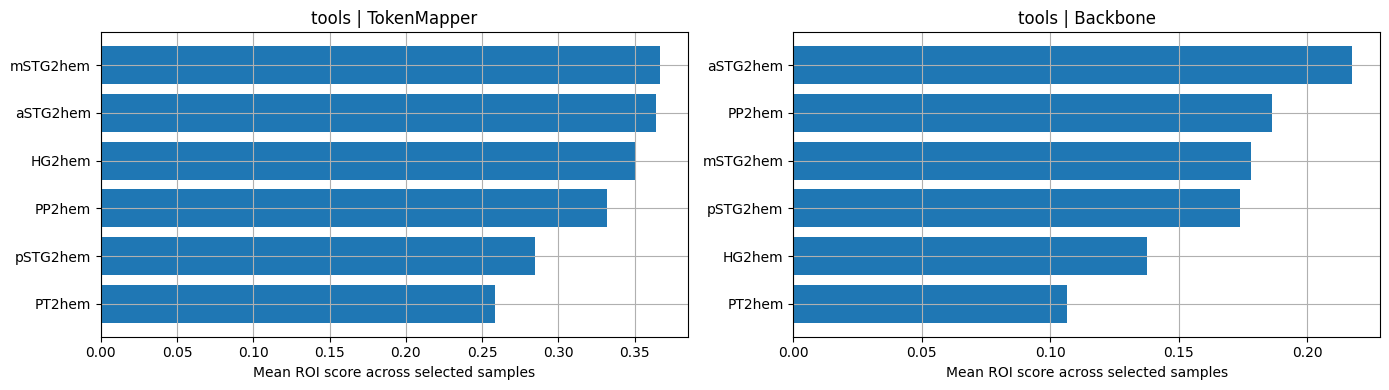

tools | TokenMapper ranking


,roi,tokenmapper_roi_score
4,mSTG2hem,0.366272
3,aSTG2hem,0.363794
0,HG2hem,0.350880
1,PP2hem,0.331873
5,pSTG2hem,0.284910
2,PT2hem,0.258480


tools | Backbone ranking


,roi,roi_backbone_score
3,aSTG2hem,0.217428
1,PP2hem,0.186269
4,mSTG2hem,0.178272
5,pSTG2hem,0.173900
0,HG2hem,0.137699
2,PT2hem,0.106433


In [9]:
category_results = {}
for category_name, sample_list in CATEGORY_TO_SAMPLE_INDICES.items():
    token_df, backbone_df = plot_group_barplots(
        sample_indices=sample_list,
        group_name=category_name,
        save_prefix=f'category_{category_name}',
    )
    category_results[category_name] = {
        'token': token_df,
        'backbone': backbone_df,
    }


## 3. Single-sample results

Qui non facciamo media sui sample.

La sola media presente nella heatmap backbone e sui **processor** del backbone per ogni step, mentre gli step restano separati.

/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/torchsde/_brownian/brownian_interval.py:608: UserWarning: Should have tb<=t1 but got tb=500.00006103515625 and t1=500.0.
  warnings.warn(f"Should have {tb_name}<=t1 but got {tb_name}={tb} and t1={self._end}.")
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/torchsde/_brownian/brownian_interval.py:599: UserWarning: Should have ta>=t0 but got ta=0.29999998211860657 and t0=0.3.
  warnings.warn(f"Should have ta>=t0 but got ta={ta} and t0={self._start}.")
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/torchsde/_brownian/brownian_interval.py:599: UserWarning: Should have ta>=t0 but got ta=0.0 and t0=0.3.
  warnings.warn(f"Should have ta>=t0 but got ta={ta} and t0={self._start}.")
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/torchsde/_brownian/brownian_interval.py:602: UserWarning: Should have tb>=t0 but got tb=0.29999998211860657 and t0=0.3.
  warnings.warn(f"Should hav

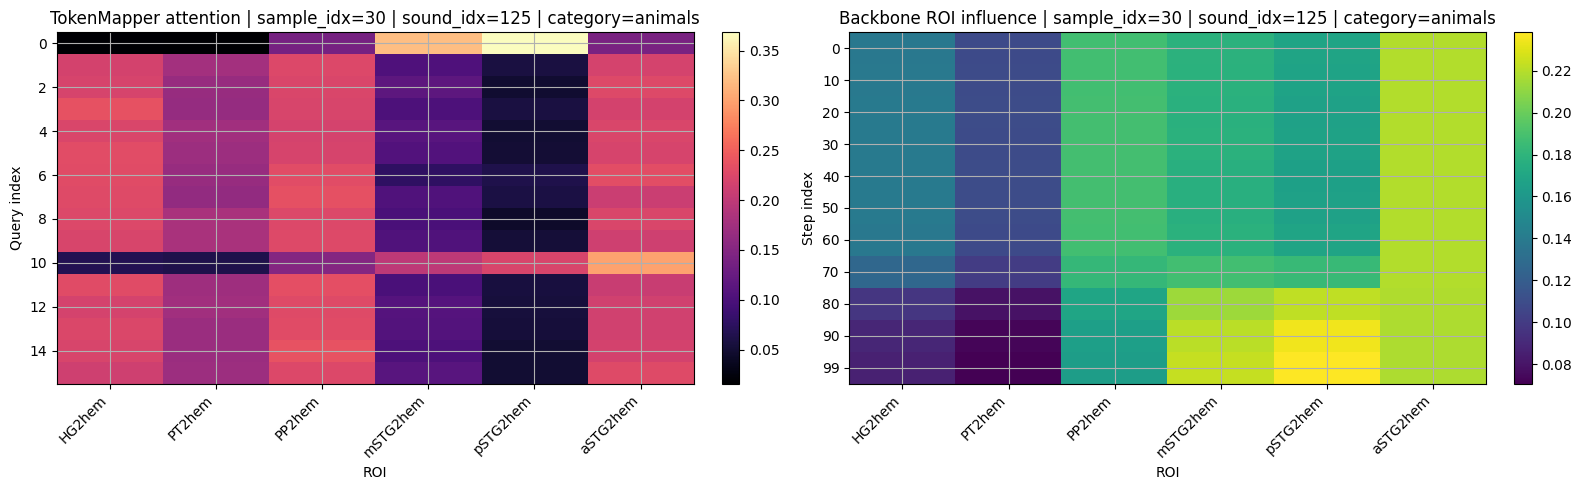

Single-sample summary


,sample_idx,sound_idx,category,tokenmapper_top_roi,tokenmapper_top_score,backbone_top_roi,backbone_top_score,token_backbone_agree
30,30,125,animals,HG2hem,0.658911,aSTG2hem,0.218683,False


In [14]:
CONFIG['single_sample_to_plot'] = 30
token_heatmap, backbone_heatmap = plot_single_sample_heatmaps(
    sample_idx=CONFIG['single_sample_to_plot'],
    save_prefix='single_sample',
)


## Optional: quick access tables

Queste tabelle aiutano a controllare quali ROI risultano dominanti per sample e per categoria.

In [11]:
print('Per-sample summary')
display(sample_summary_df)

category_top_df = sample_summary_df.groupby(['category', 'backbone_top_roi']).size().reset_index(name='count').sort_values(['category', 'count'], ascending=[True, False])
print('How often each ROI is top in the Backbone within each category')
display(category_top_df)


Per-sample summary


,sample_idx,sound_idx,category,tokenmapper_top_roi,tokenmapper_top_score,backbone_top_roi,backbone_top_score,token_backbone_agree
0,0,0,speech,mSTG2hem,0.481851,HG2hem,0.229107,False
1,1,1,speech,mSTG2hem,0.417570,PP2hem,0.229784,False
2,2,2,speech,mSTG2hem,0.395368,PP2hem,0.228675,False
3,3,10,speech,PP2hem,0.405107,PP2hem,0.230097,True
4,4,11,speech,mSTG2hem,0.518544,HG2hem,0.230592,False
...,...,...,...,...,...,...,...,...
67,67,265,tools,HG2hem,0.339613,aSTG2hem,0.217870,False
68,68,266,tools,HG2hem,0.428461,aSTG2hem,0.215707,False
69,69,267,tools,aSTG2hem,0.291074,aSTG2hem,0.218129,True
70,70,274,tools,aSTG2hem,0.354740,aSTG2hem,0.218204,True


How often each ROI is top in the Backbone within each category


,category,backbone_top_roi,count
1,animals,aSTG2hem,11
0,animals,PP2hem,1
2,music,aSTG2hem,12
3,nature,aSTG2hem,11
4,nature,pSTG2hem,1
5,speech,HG2hem,7
6,speech,PP2hem,5
7,tools,aSTG2hem,12
8,voice,HG2hem,6
9,voice,PP2hem,3
